### 01 · Quickstart — Your First Metalens in 60 Seconds

This notebook designs a working visible-band metalens end-to-end using
nothing but the **analytical backend** — no TensorFlow, no metabox3.
It's the fastest sanity check that our install is healthy.

**What we'll see:**
- The five canonical stages: *materials → sweep → phase → propagate → analyze*.
- A focal-spot PSF for a TiO₂ metalens at 532 nm.
- Strehl ratio + FWHM as quality metrics.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

### 1 · Compose the runtime

Three primitives wire the stack: an **artifact store** (handles for
intermediate payloads), a **backend registry** (which RCWA implementation
to use), and a **tool registry** (the LLM-facing surface).

In [2]:
from metaopticsai.store.memory import InMemoryArtifactStore
from metaopticsai.physics.backends.base import BackendRegistry
from metaopticsai.physics.backends.analytical import AnalyticalBackend
from metaopticsai.tools import build_tool_registry

store = InMemoryArtifactStore()
backends = BackendRegistry()
backends.register(AnalyticalBackend())  # no TF, no metabox3
tools = build_tool_registry(store, backends)

print(f"Registered {len(list(tools.names()))} tools:")
for name in sorted(tools.names()):
    print(f"  · {name}")

Registered 15 tools:
  · analyze_mtf
  · analyze_psf
  · compute_center_intensity
  · compute_max_intensity
  · compute_mtf_volume
  · export_gds
  · generate_phase_mask
  · get_fdtd_library
  · get_material_index
  · list_artifacts
  · list_materials
  · optimize_metalens
  · propagate_field
  · run_rcwa_sweep
  · zernike_decompose


### **2 Stage 1: Pick a material**

The `list_materials` tool exposes every refractive-index CSV bundled
with the metabox3 material library.

In [3]:
result = tools.get("list_materials").call_sync({})
print(f"{result['count']} materials available.")
print("First 10:", result["materials"][:10])

12 materials available.
First 10: ['GaN', 'MoO3', 'N-BK7', 'Nb2O5', 'Si3N4', 'Si_ir', 'Si_visible', 'TiO2', 'ZnO', 'ZrO2']


### **3 Stage 2: RCWA meta-atom sweep**

Build a phase-vs-diameter library by sweeping the pillar diameter at a
single wavelength. The analytical backend uses a sigmoid heuristic — fast
but not Maxwell-rigorous.

In [4]:
sweep = tools.get("run_rcwa_sweep").call_sync({
    "wavelength_nm": 532,
    "pillar_material": "TiO2",
    "pillar_height_nm": 600.0,
    "period_nm": 350.0,
    "min_diameter_nm": 50.0,
    "max_diameter_nm": 250.0,
    "n_samples": 30,
    "xy_harmonics": 5,
})
print(f"Phase coverage: {sweep['phase_coverage_2pi_fraction']:.3f} × 2π")
print(f"Mean transmission: {sweep['mean_transmission']:.3f}")
print(f"Backend: {sweep['backend']}")
print(f"Advice: {sweep['advice']}")

Phase coverage: 0.702 × 2π
Mean transmission: 0.995
Backend: analytical
Advice: Phase coverage < 0.9 — increase pillar_height_nm or widen the diameter range.


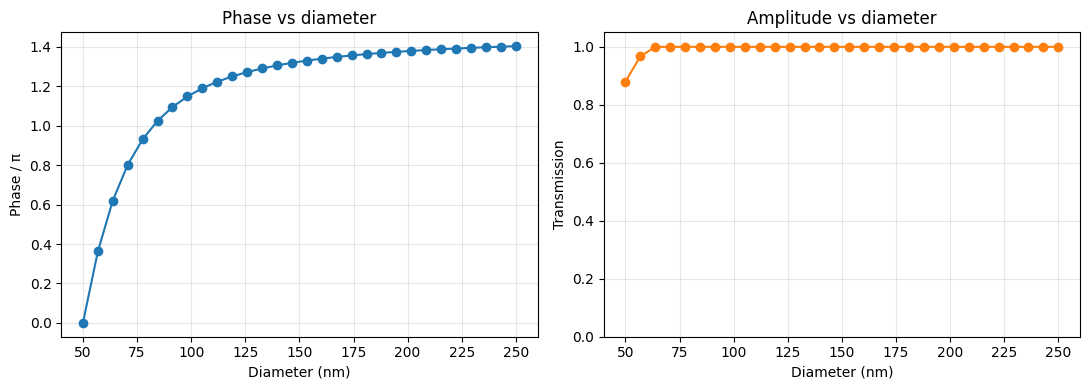

In [5]:
# Inspect the underlying artifact
sweep_data = store.get(sweep["handle"]).payload
diam = np.array(sweep_data["diameters_nm"])
amp  = np.array(sweep_data["amplitudes"])
phase = np.array(sweep_data["phases_rad"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(diam, phase / np.pi, "o-")
ax1.set(xlabel="Diameter (nm)", ylabel="Phase / π", title="Phase vs diameter")
ax1.grid(alpha=.3)
ax2.plot(diam, amp, "o-", color="tab:orange")
ax2.set(xlabel="Diameter (nm)", ylabel="Transmission", title="Amplitude vs diameter")
ax2.set_ylim(0, 1.05)
ax2.grid(alpha=.3)
plt.tight_layout()

### **4 Stage 3: Generate a Fresnel-zone phase mask**

Mask shape: (142, 142), phase range: [0.00, 6.28] rad


Text(0.5, 1.0, 'Continuous FZL phase profile')

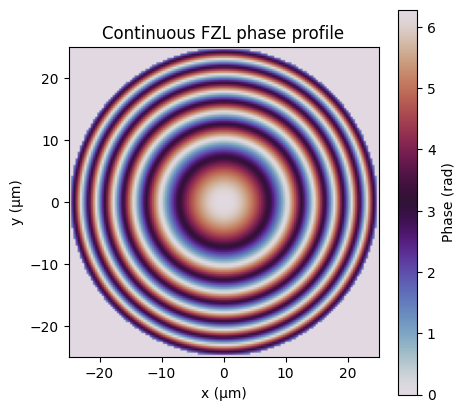

In [6]:
mask = tools.get("generate_phase_mask").call_sync({
    "mask_type": "fzl",
    "wavelength_nm": 532,
    "focal_length_um": 100.0,
    "diameter_um": 50.0,
    "pixel_size_um": 0.35,
})
phase_mask = store.get(mask["handle"]).payload
print(f"Mask shape: {phase_mask.shape}, phase range: "
      f"[{phase_mask.min():.2f}, {phase_mask.max():.2f}] rad")

plt.figure(figsize=(5, 5))
plt.imshow(phase_mask, cmap="twilight", extent=[-25, 25, -25, 25])
plt.colorbar(label="Phase (rad)")
plt.xlabel("x (µm)"); plt.ylabel("y (µm)")
plt.title("Continuous FZL phase profile")

### **5 Stage 4: Compute the PSF**

We propagate the phase mask to the focal plane via Fraunhofer
diffraction and measure the focal spot.

Strehl ratio: 0.001
FWHM (x):     2.681 µm


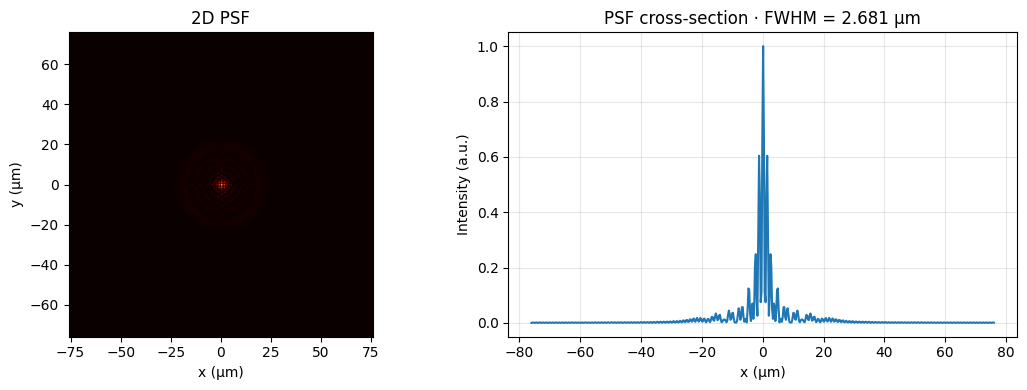

In [7]:
psf = tools.get("analyze_psf").call_sync({
    "mask_handle": mask["handle"],
    "wavelength_nm": 532,
    "pixel_size_um": 0.35,
    "focal_length_um": 100.0,
    "pad_factor": 4,
})
print(f"Strehl ratio: {psf['strehl_ratio']:.3f}")
print(f"FWHM (x):     {psf['fwhm_x_um']:.3f} µm")

psf_data = store.get(psf["handle"]).payload
psf_2d = psf_data["psf_2d"]
x_um = psf_data["x_um"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ext = [x_um.min(), x_um.max(), x_um.min(), x_um.max()]
ax1.imshow(psf_2d, extent=ext, cmap="hot")
ax1.set(xlabel="x (µm)", ylabel="y (µm)", title="2D PSF")

center = psf_2d.shape[0] // 2
ax2.plot(x_um, psf_2d[center, :])
ax2.set(xlabel="x (µm)", ylabel="Intensity (a.u.)",
        title=f"PSF cross-section · FWHM = {psf['fwhm_x_um']:.3f} µm")
ax2.grid(alpha=.3)
plt.tight_layout()

### 6 Stage 5: MTF**

Modulation Transfer Function is the autocorrelation of the PSF in
frequency space — the standard image-quality metric.

MTF50: 10.4 lp/mm
Cutoff (diffraction limit): 1418.5 lp/mm


Text(0.5, 1.0, 'Radial MTF vs diffraction limit')

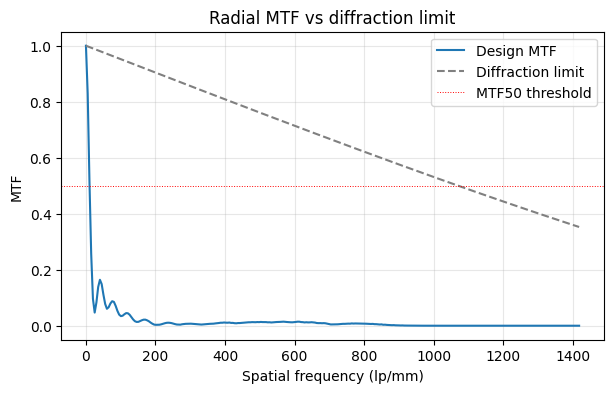

In [8]:
mtf = tools.get("analyze_mtf").call_sync({
    "psf_handle": psf["handle"],
    "pixel_size_um": 0.35,
    "wavelength_nm": 532,
    "focal_length_um": 100.0,
})
mtf_data = store.get(mtf["handle"]).payload
freqs = np.array(mtf_data["freqs_lpmm"])
mtf_r = np.array(mtf_data["mtf_radial"])
mtf_d = np.array(mtf_data["mtf_diffraction_limit"])

print(f"MTF50: {mtf['mtf50_lpmm']:.1f} lp/mm")
print(f"Cutoff (diffraction limit): {mtf['cutoff_lpmm']:.1f} lp/mm")

plt.figure(figsize=(7, 4))
plt.plot(freqs, mtf_r, label="Design MTF")
plt.plot(freqs, mtf_d, "--", color="gray", label="Diffraction limit")
plt.axhline(0.5, color="r", lw=0.7, ls=":", label="MTF50 threshold")
plt.xlabel("Spatial frequency (lp/mm)")
plt.ylabel("MTF")
plt.legend(); plt.grid(alpha=.3); plt.title("Radial MTF vs diffraction limit")

## Where to go next

- `02_metalens_design_pipeline.ipynb` — same stages, but with detailed
  step-by-step commentary and intermediate visualizations.
- `03_advanced_analysis.ipynb` — Zernike decomposition + propagation at
  multiple defocus planes.
- `04_tool_layer_for_agents.ipynb` — the same operations expressed in
  the agent-facing tool API.
- `05_self_rag_automl.ipynb` — natural-language requirement → GDS file
  via the LangGraph Self-RAG workflow.